<a href="https://colab.research.google.com/github/ankitadhara28/Social-Media-Detox-/blob/main/Social_Media_Detox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
%matplotlib inline

# Upload dataset
from google.colab import files
uploaded = files.upload()

# Loading CSV into Pandas DataFrame
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

# Displaying first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

# Get basic info about dataset
print("\nDataset Info:")
df.info()

# Summary statistics for numeric columns
print("\nSummary statistics:")
display(df.describe())

# Check for missing values
print("\nMissing values in each column:")
display(df.isnull().sum())


Saving Students Social Media Addiction (1).csv to Students Social Media Addiction (1).csv
First 5 rows of the dataset:


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,353.000000,20.659574,4.918723,6.868936,6.226950,2.849645,6.436879
std,203.660256,1.399217,1.257395,1.126848,1.105055,0.957968,1.587165
min,1.000000,18.000000,1.500000,3.800000,4.000000,0.000000,2.000000
25%,177.000000,19.000000,4.100000,6.000000,5.000000,2.000000,5.000000
50%,353.000000,21.000000,4.800000,6.900000,6.000000,3.000000,7.000000
75%,529.000000,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000
max,705.000000,24.000000,8.500000,9.600000,9.000000,5.000000,9.000000



Missing values in each column:


,0
Student_ID,0
Age,0
Gender,0
Academic_Level,0
Country,0
Avg_Daily_Usage_Hours,0
Most_Used_Platform,0
Affects_Academic_Performance,0
Sleep_Hours_Per_Night,0
Mental_Health_Score,0


In [ ]:
# Define the list of categorical columns in the dataset
categorical_cols = ['Gender', 'Academic_Level', 'Country', 'Most_Used_Platform',
                    'Affects_Academic_Performance', 'Relationship_Status']

# Convert these selected columns into 'category' data type for efficient storage and analysis
for col in categorical_cols:
    df[col] = df[col].astype('category')

# Created a new column 'Age_Group' by binning the continuous 'Age' column into groups
# Bins: (17-19], (19-21], (21-24]
# Labels assigned to each bin: '18-19', '20-21', '22-24'
df['Age_Group'] = pd.cut(df['Age'], bins=[17,19,21,24], labels=['18-19','20-21','22-24'])
df['Age_Group'] = df['Age_Group'].astype('category')

# Displaying first 5 rows
print("First 5 rows with Age_Group:")
display(df.head())

# Show the updated data types of all columns to confirm the conversions
print("\nColumn data types after conversion:")
display(df.dtypes)


First 5 rows with Age_Group:


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score,Age_Group
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8,18-19
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3,22-24
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9,20-21
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4,18-19
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7,20-21



Column data types after conversion:


,0
Student_ID,int64
Age,int64
Gender,category
Academic_Level,category
Country,category
Avg_Daily_Usage_Hours,float64
Most_Used_Platform,category
Affects_Academic_Performance,category
Sleep_Hours_Per_Night,float64
Mental_Health_Score,int64


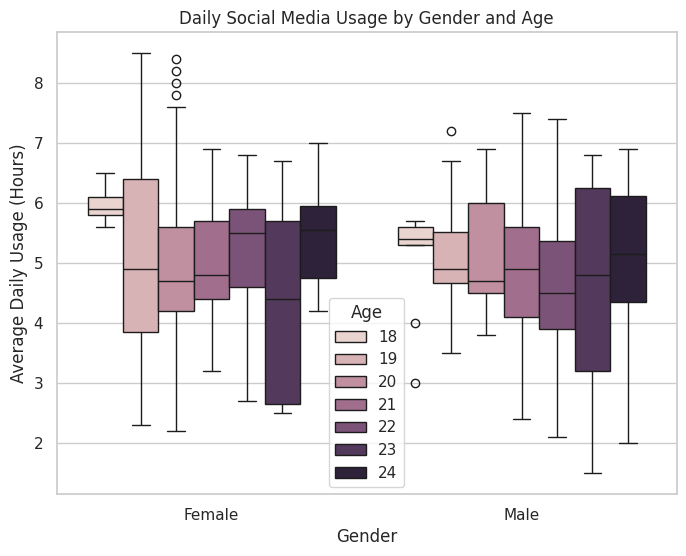

Average Daily Usage (Hours) by Gender and Age:


/tmp/ipython-input-579368188.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_usage = df.groupby(["Gender", "Age"])["Avg_Daily_Usage_Hours"].mean().reset_index()


,Gender,Age,Avg_Daily_Usage_Hours
0,Female,18,5.980000
1,Female,19,5.128889
2,Female,20,4.904110
3,Female,21,5.035484
4,Female,22,5.069231
5,Female,23,4.326667
6,Female,24,5.462500
7,Male,18,5.055556
8,Male,19,5.078571
9,Male,20,5.131579


In [ ]:
# Set figure size for the plot
plt.figure(figsize=(8,6))

# Create a boxplot to show distribution of daily social media usage
# x-axis = Gender, y-axis = Avg_Daily_Usage_Hours, hue = Age (different colors for each age
sns.boxplot(x='Gender', y='Avg_Daily_Usage_Hours', hue='Age', data=df)

# Set title and axis labels
plt.title("Daily Social Media Usage by Gender and Age")
plt.xlabel("Gender")
plt.ylabel("Average Daily Usage (Hours)")
plt.legend(title='Age')

# Display the plot
plt.show()

# Print the groupby table for reference
avg_usage = df.groupby(["Gender", "Age"])["Avg_Daily_Usage_Hours"].mean().reset_index()
print("Average Daily Usage (Hours) by Gender and Age:")
display(avg_usage)


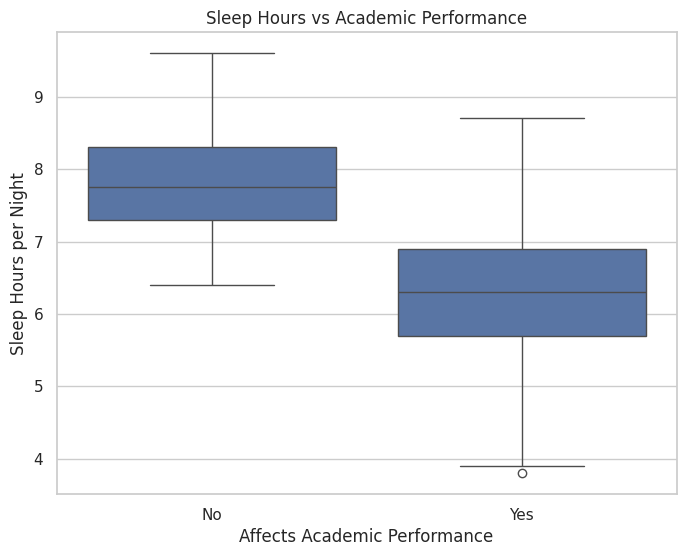

Average Sleep Hours by Academic Performance:


/tmp/ipython-input-3106335531.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_sleep = df.groupby("Affects_Academic_Performance")["Sleep_Hours_Per_Night"].mean()


,Sleep_Hours_Per_Night
Affects_Academic_Performance,
No,7.813095
Yes,6.343709


In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Affects_Academic_Performance', y='Sleep_Hours_Per_Night', data=df)
plt.title("Sleep Hours vs Academic Performance")
plt.xlabel("Affects Academic Performance")
plt.ylabel("Sleep Hours per Night")

plt.show()

# Print the groupby table for reference
avg_sleep = df.groupby("Affects_Academic_Performance")["Sleep_Hours_Per_Night"].mean()
print("Average Sleep Hours by Academic Performance:")
display(avg_sleep)


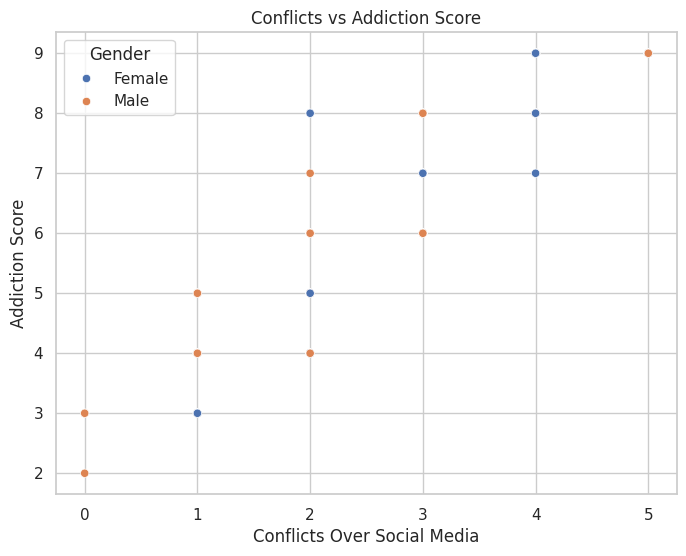

Average Addiction Score by Conflict Level:


,Addicted_Score
Conflicts_Over_Social_Media,
0,2.750000
1,3.851064
2,4.848039
3,6.862069
4,8.224138
5,9.000000


In [ ]:
# Set figure size
plt.figure(figsize=(8,6))

# Create scatter plot
# x-axis = number of conflicts over social media
# y-axis = addiction score
# hue = Gender, to differentiate males and females
sns.scatterplot(x='Conflicts_Over_Social_Media', y='Addicted_Score', hue='Gender', data=df)
plt.title("Conflicts vs Addiction Score")
plt.xlabel("Conflicts Over Social Media")
plt.ylabel("Addiction Score")

# Display the plot
plt.show()

avg_conflict = df.groupby("Conflicts_Over_Social_Media")["Addicted_Score"].mean()
print("Average Addiction Score by Conflict Level:")
display(avg_conflict)



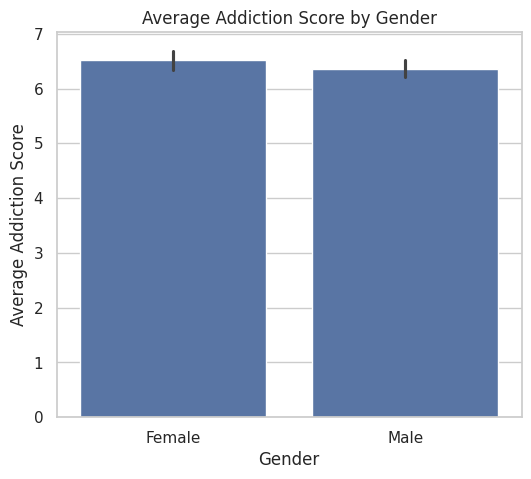

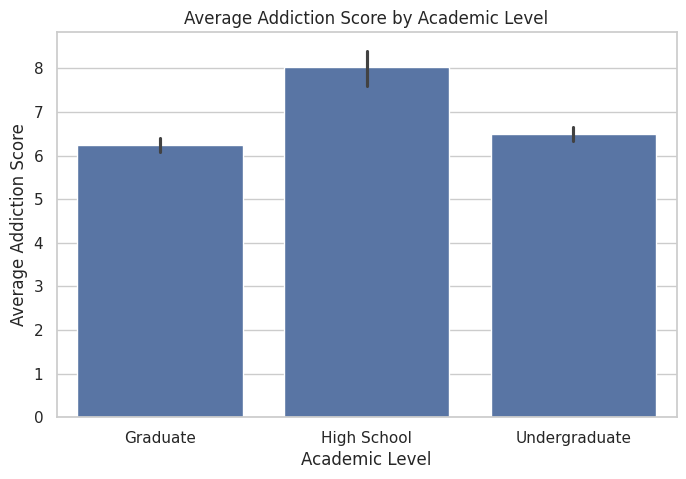

Addiction Score across Gender and Academic Level:


/tmp/ipython-input-1460158116.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_demo = df.groupby(["Gender","Academic_Level"])["Addicted_Score"].mean().reset_index()


,Gender,Academic_Level,Addicted_Score
0,Female,Graduate,6.104167
1,Female,High School,8.466667
2,Female,Undergraduate,6.482759
3,Male,Graduate,6.267148
4,Male,High School,7.500000
5,Male,Undergraduate,6.539683


In [ ]:
# Set figure size
plt.figure(figsize=(6,5))
# 1. Bar Chart: Average Addiction Score by Gender
sns.barplot(x='Gender', y='Addicted_Score', data=df, estimator=np.mean)
plt.title("Average Addiction Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Addiction Score")
plt.show()

# Set figure size
plt.figure(figsize=(8,5))
# 2. Bar Chart: Average Addiction Score by Academic Level
sns.barplot(x='Academic_Level', y='Addicted_Score', data=df, estimator=np.mean)
plt.title("Average Addiction Score by Academic Level")
plt.xlabel("Academic Level")
plt.ylabel("Average Addiction Score")
plt.show()

avg_demo = df.groupby(["Gender","Academic_Level"])["Addicted_Score"].mean().reset_index()
print("Addiction Score across Gender and Academic Level:")
# Display the table
display(avg_demo)



In [ ]:
# 1. Average Addiction Score by Gender
# Group data by 'Gender' and calculate mean addiction score
avg_by_gender = df.groupby("Gender")["Addicted_Score"].mean()
print("Average Addiction Score by Gender:")
display(avg_by_gender)


# 2. Average Addiction Score by Age
# Group data by 'Age' and calculate mean addiction score
avg_by_age = df.groupby("Age")["Addicted_Score"].mean()
print("\nAverage Addiction Score by Age:")
display(avg_by_age)


# 3. Average Addiction Score by Academic Level
# Group data by 'Academic_Level' and calculate mean addiction score
avg_by_edu = df.groupby("Academic_Level")["Addicted_Score"].mean()
print("\nAverage Addiction Score by Academic Level:")
display(avg_by_edu)


Average Addiction Score by Gender:


/tmp/ipython-input-1364561133.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_gender = df.groupby("Gender")["Addicted_Score"].mean()


,Addicted_Score
Gender,
Female,6.515581
Male,6.357955



Average Addiction Score by Age:


,Addicted_Score
Age,
18,7.785714
19,6.650307
20,6.478788
21,6.589744
22,6.095238
23,5.676471
24,6.115385



Average Addiction Score by Academic Level:


/tmp/ipython-input-1364561133.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_edu = df.groupby("Academic_Level")["Addicted_Score"].mean()


,Addicted_Score
Academic_Level,
Graduate,6.243077
High School,8.037037
Undergraduate,6.492918


In [ ]:

def classify_risk(usage_hours):
    if usage_hours < 3:
        return "Low"
    elif 3 <= usage_hours <= 6:
        return "Medium"
    else:
        return "High"

df["Risk_Level"] = df["Avg_Daily_Usage_Hours"].apply(classify_risk)

print("First 5 rows with Risk Level classification:")
display(df[["Avg_Daily_Usage_Hours", "Risk_Level"]].head())

def detox_strategy(risk):
    if risk == "Low":
        return "Maintain healthy habits, track screen time."
    elif risk == "Medium":
        return "Set daily limits, replace screen time with hobbies."
    else:  # High risk
        return "Seek counseling, schedule screen-free hours, use app blockers."

df["Detox_Strategy"] = df["Risk_Level"].apply(detox_strategy)

print("First 5 rows with Detox Strategies:")
display(df[["Avg_Daily_Usage_Hours", "Risk_Level", "Detox_Strategy"]].head())


First 5 rows with Risk Level classification:


,Avg_Daily_Usage_Hours,Risk_Level
0,5.2,Medium
1,2.1,Low
2,6.0,Medium
3,3.0,Medium
4,4.5,Medium


First 5 rows with Detox Strategies:


,Avg_Daily_Usage_Hours,Risk_Level,Detox_Strategy
0,5.2,Medium,"Set daily limits, replace screen time with hob..."
1,2.1,Low,"Maintain healthy habits, track screen time."
2,6.0,Medium,"Set daily limits, replace screen time with hob..."
3,3.0,Medium,"Set daily limits, replace screen time with hob..."
4,4.5,Medium,"Set daily limits, replace screen time with hob..."


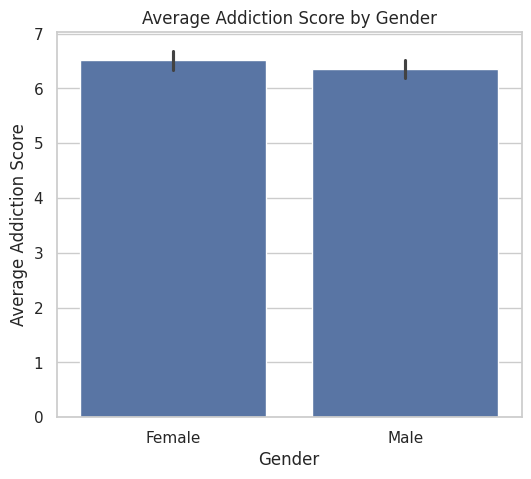

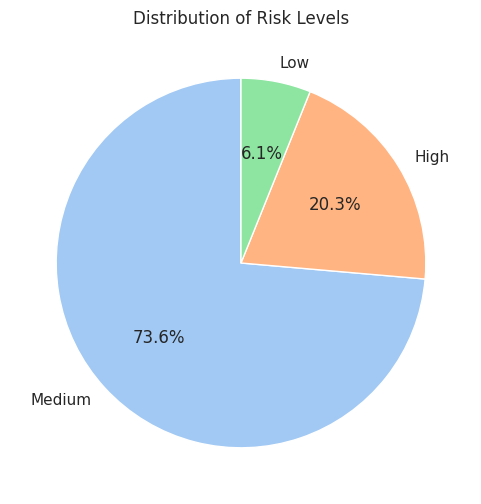

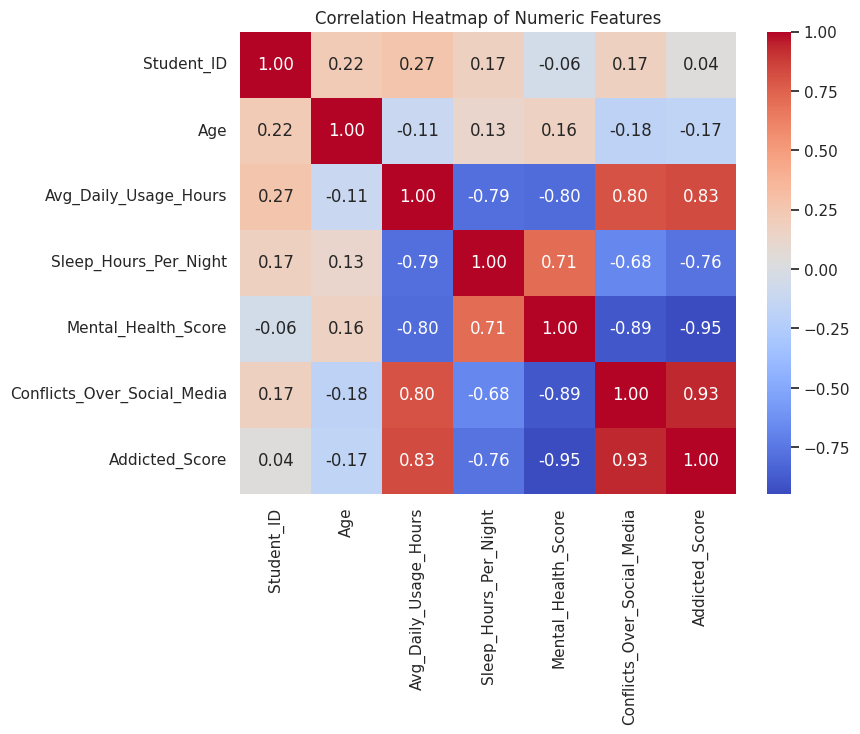

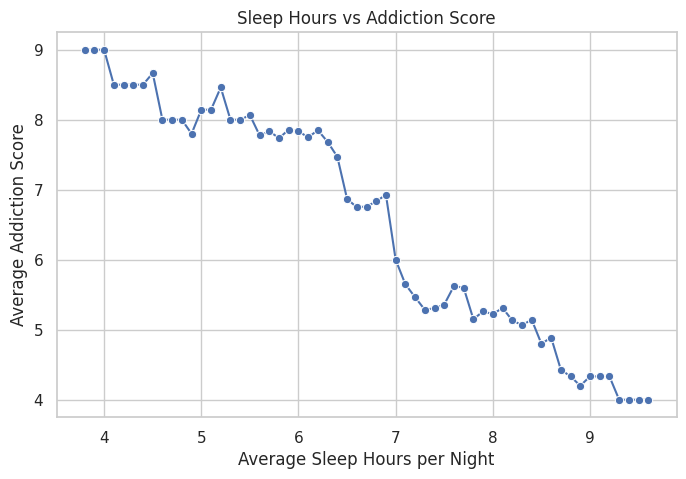

In [ ]:

# 1. Bar Chart: Average Addiction Score by Gende
plt.figure(figsize=(6,5))
sns.barplot(x='Gender', y='Addicted_Score', data=df, estimator=np.mean)
plt.title("Average Addiction Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Addiction Score")
plt.show()

# 2. Pie Chart: Distribution of Risk Levels
risk_counts = df["Risk_Level"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
plt.title("Distribution of Risk Levels")
plt.show()

# 3. Heatmap: Correlation between numeric features
numeric_df = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

# 4. Line Plot: Sleep Hours vs Addiction Score
avg_sleep_addiction = df.groupby("Sleep_Hours_Per_Night")["Addicted_Score"].mean().reset_index()
plt.figure(figsize=(8,5))
sns.lineplot(x="Sleep_Hours_Per_Night", y="Addicted_Score", data=avg_sleep_addiction, marker="o")
plt.title("Sleep Hours vs Addiction Score")
plt.xlabel("Average Sleep Hours per Night")
plt.ylabel("Average Addiction Score")
plt.show()




**10 Line Story Telling Summary :**

1. The dataset revealed that students, especially in younger age groups, are spending several hours daily on social media.

2. Female students and undergraduates showed slightly higher average daily usage compared to others.

3. Sleep duration was inversely related to addiction — fewer sleep hours linked to higher addiction scores.

4. Academic performance was negatively impacted for many students with longer daily usage.

5. Conflicts over social media were strongly tied to higher addiction scores, highlighting strained relationships.

6. Correlation analysis confirmed that daily usage hours and conflicts were the strongest predictors of addiction.

7. Risk-level classification showed a majority of students fell into the medium and high-risk groups.

8. The root causes identified were prolonged daily usage, disrupted sleep, and peer/social conflicts.

9. Recommended actions include digital detox strategies such as screen-time limits, scheduled breaks, and awareness programs.

10. Schools, parents, and students together must encourage healthier habits to reduce the negative impacts of social media addiction.

In [ ]:
!jupyter nbconvert --to html miniproject.ipynb

[NbConvertApp] Converting notebook miniproject.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 9 image(s).
[NbConvertApp] Writing 806119 bytes to miniproject.html
